In [50]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import particle
from particle import Particle

#PATH = pathlib.Path(__file__).parent.resolve()
DET_I = 5 #SBND ?
DET_A = 4*np.pi*1e4# Find detector area

flavours = {
     14: (r"$\nu_\mu$",     "blue"),
    -14: (r"$\bar\nu_\mu$", "orange"),
     12: (r"$\nu_e$",       "green"),
    -12: (r"$\bar\nu_e$",   "red"),
}


In [ ]:
with uproot.open("./NuBeam_production_BooNE_50m_I174000A_0.dk2nu.root") as f:
    
    tree = f[f.keys()[0]]
    meta = f[f.keys()[2]]

    nuray_E   = tree["nuray"]["nuray.E"].array()
    nuray_wgt = tree["nuray"]["nuray.wgt"].array()
    nimpwt   = tree["decay"]["decay.nimpwt"].array()
    ntype     = tree["decay"]["decay.ntype"].array()
    ptype     = tree["decay"]["decay.ptype"].array() 

    pots = meta["pots"].array()

    for entry in tree:
        print(entry.name)
        for entry2 in entry:
            print("\t",entry2.name)
            for entry3 in entry2:
                print("\t\t",entry3.name)

<TBranchElement 'dk2nu' (13 subbranches) at 0x7c8a8e2db750>
	 <TBranchElement 'job' at 0x7c8a8e2d8850>
	 <TBranchElement 'potnum' at 0x7c8a8e2db250>
	 <TBranchElement 'decay' (21 subbranches) at 0x7c8aa8665750>
	 <TBranchElement 'nuray' (5 subbranches) at 0x7c8aa97d3c50>
	 <TBranchElement 'ancestor' (22 subbranches) at 0x7c8a8e074950>
	 <TBranchElement 'ppvx' at 0x7c8a8e077750>
	 <TBranchElement 'ppvy' at 0x7c8a8e077950>
	 <TBranchElement 'ppvz' at 0x7c8a8e077b50>
	 <TBranchElement 'tgtexit' (8 subbranches) at 0x7c8a8e077d50>
	 <TBranchElement 'traj' (6 subbranches) at 0x7c8aa818d050>
	 <TBranchElement 'flagbits' at 0x7c8aa818de50>
	 <TBranchElement 'vint' at 0x7c8aa818e050>
	 <TBranchElement 'vdbl' at 0x7c8aa818e250>


In [52]:
# Select SBND
energies = nuray_E[:,DET_I]
wgts     = nuray_wgt[:,DET_I]
tot_wgts = nimpwt * wgts / (DET_A * pots[0])

# Type and Parents
is_numu      = (ntype == 14)
is_anumu     = (ntype == -14)
is_nue       = (ntype == 12)
is_anue      = (ntype == -12)

parent_groups = {
    "mu" : (np.isin(ptype, [13,-13]), "blue"),
    "pi" : (np.isin(ptype, [211,-211]), "orange"),
    "K0L" : (np.isin(ptype, [130]), "red"),
    "Kpm" : (np.isin(ptype, [321, -321]), "green")
}

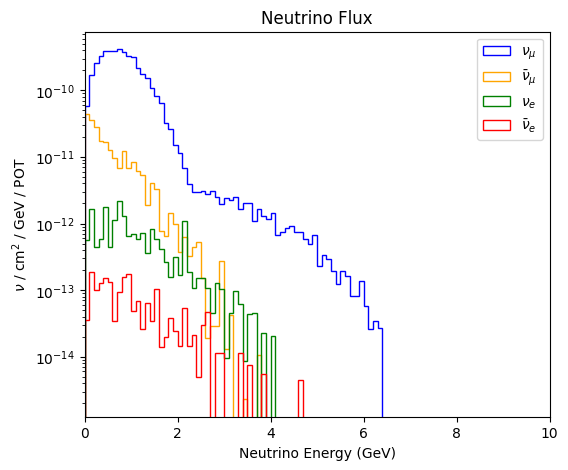

In [53]:
fig, ax = plt.subplots(figsize=(6, 5))
bins = np.linspace(0, 10, 101)  # GeV


for pdg, (label, colour) in flavours.items():
    mask = (ntype == pdg)
    ax.hist(energies[mask], bins=bins, weights=tot_wgts[mask],
            label=label, color=colour, histtype="step", linewidth=1)

ax.set_xlabel("Neutrino Energy (GeV)")
ax.set_xlim(0,10)
ax.set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
ax.set_title("Neutrino Flux")
ax.legend()
ax.set_yscale("log")

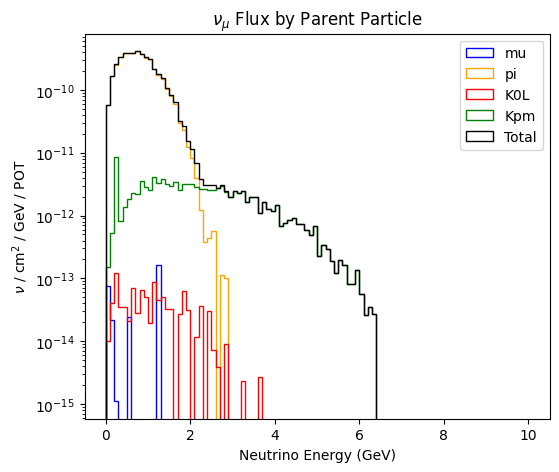

In [54]:
fig, ax = plt.subplots(figsize=(6, 5))
bins = np.linspace(0, 10, 101)  # GeV

for label, (parent_mask, colour) in parent_groups.items():
    mask = is_numu & parent_mask
    ax.hist(energies[mask], bins=bins, weights=tot_wgts[mask],
            label=label, color=colour, histtype="step", linewidth=1)

# Total Flux
ax.hist(energies[is_numu], bins=bins, weights=tot_wgts[is_numu], label="Total", 
        color="black", histtype="step", linewidth=1)

ax.set_xlabel("Neutrino Energy (GeV)")
ax.set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
ax.set_title(r"$\nu_\mu$ Flux by Parent Particle")
ax.legend()
ax.set_yscale("log")
#ax.set_xlim(0,1)

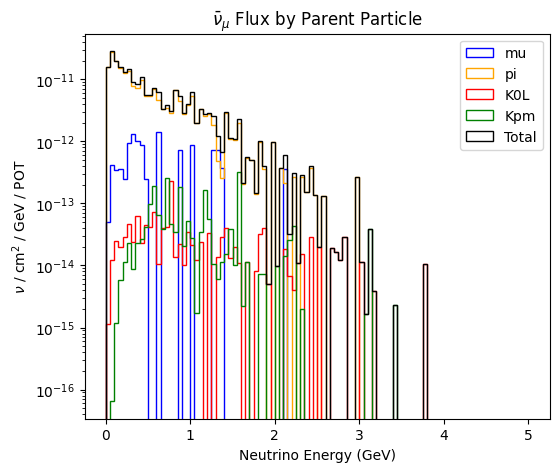

In [55]:
fig, ax = plt.subplots(figsize=(6, 5))
bins = np.linspace(0, 5, 101)  # GeV

for label, (parent_mask, colour) in parent_groups.items():
    mask = is_anumu & parent_mask
    ax.hist(energies[mask], bins=bins, weights=tot_wgts[mask],
            label=label, color=colour, histtype="step", linewidth=1)

# Total Flux
ax.hist(energies[is_anumu], bins=bins, weights=tot_wgts[is_anumu], label="Total", 
        color="black", histtype="step", linewidth=1)

ax.set_xlabel("Neutrino Energy (GeV)")
ax.set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
ax.set_title(r"$\bar{\nu}_\mu$ Flux by Parent Particle")
ax.legend()
ax.set_yscale("log")

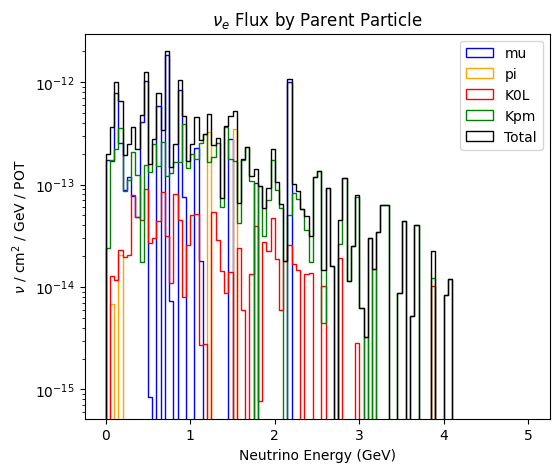

In [56]:
fig, ax = plt.subplots(figsize=(6, 5))
bins = np.linspace(0, 5, 101)  # GeV

for label, (parent_mask, colour) in parent_groups.items():
    mask = is_nue & parent_mask
    ax.hist(energies[mask], bins=bins, weights=tot_wgts[mask],
            label=label, color=colour, histtype="step", linewidth=1)

# Total Flux
ax.hist(energies[is_nue], bins=bins, weights=tot_wgts[is_nue], label="Total", 
        color="black", histtype="step", linewidth=1)

ax.set_xlabel("Neutrino Energy (GeV)")
ax.set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
ax.set_title(r"$\nu_e$ Flux by Parent Particle")
ax.legend()
ax.set_yscale("log")

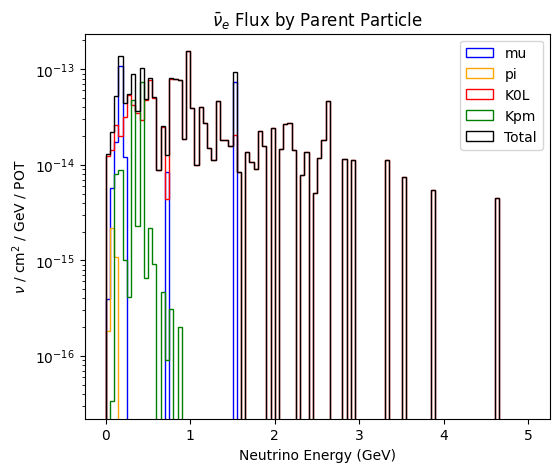

In [57]:
fig, ax = plt.subplots(figsize=(6, 5))
bins = np.linspace(0, 5, 101)  # GeV

for label, (parent_mask, colour) in parent_groups.items():
    mask = is_anue & parent_mask
    ax.hist(energies[mask], bins=bins, weights=tot_wgts[mask],
            label=label, color=colour, histtype="step", linewidth=1)

# Total Flux
ax.hist(energies[is_anue], bins=bins, weights=tot_wgts[is_anue], label="Total", 
        color="black", histtype="step", linewidth=1)

ax.set_xlabel("Neutrino Energy (GeV)")
ax.set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
ax.set_title(r"$\bar{\nu}_e$ Flux by Parent Particle")
ax.legend()
ax.set_yscale("log")